# KMeans clustering is applied on one image

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from PIL import Image #PIL = Python Image Library

In [ ]:
img = Image.open('/content/content my_image4.png.jpeg')

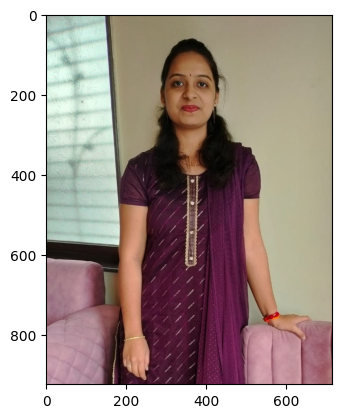

In [ ]:
plt.imshow(img)

In [ ]:
img_array = np.array(img)

array([[[145, 152, 144],
        [146, 153, 145],
        [147, 154, 146],
        ...,
        [151, 145, 123],
        [151, 145, 123],
        [151, 145, 123]],

       [[151, 158, 150],
        [152, 159, 151],
        [153, 160, 152],
        ...,
        [151, 145, 123],
        [151, 145, 123],
        [151, 145, 123]],

       [[163, 170, 162],
        [155, 162, 154],
        [147, 157, 148],
        ...,
        [151, 145, 123],
        [151, 145, 123],
        [151, 145, 123]],

       ...,

       [[198, 159, 177],
        [196, 157, 175],
        [193, 154, 172],
        ...,
        [171, 121, 122],
        [178, 128, 129],
        [119,  69,  70]],

       [[197, 158, 176],
        [195, 156, 174],
        [191, 152, 170],
        ...,
        [173, 123, 124],
        [176, 126, 127],
        [116,  66,  67]],

       [[197, 158, 176],
        [194, 155, 173],
        [190, 151, 169],
        ...,
        [175, 125, 126],
        [176, 126, 127],
        [114,  64,  65]]], dtype=uint8)
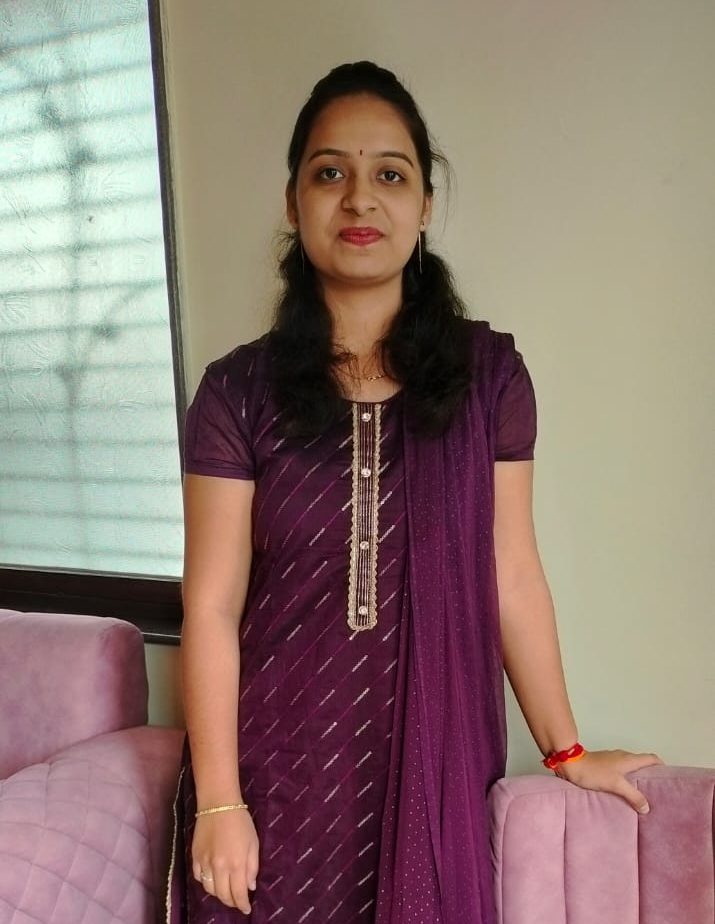

In [ ]:
img_array

In [ ]:
h, w, c = img_array.shape

In [ ]:
h

924

In [ ]:
w

715

In [ ]:
c

3

In [ ]:
pixels = img_array.reshape(h*w, c) # Individual points, P1, P2, P3 and so on

In [ ]:
model = KMeans(n_clusters=5)
group_number = model.fit_predict(pixels)

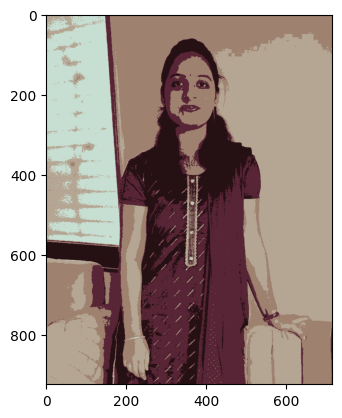

In [ ]:
segmented_image = model.cluster_centers_[group_number].reshape(h,w,c).astype(np.uint8)
plt.imshow(segmented_image)

In [ ]:
# .dcm which a way to store medical scans
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.5 MB/s eta 0:00:00


In [ ]:
# Removed pydicom as it's not suitable for JPEG files.
# import pydicom
# img = pydicom.dcmread('/content/content my_image4.png.jpeg', force=True)

# Revert to using PIL for loading the JPEG image
from PIL import Image
img = Image.open('/content/content my_image4.png.jpeg')

In [ ]:
import pydicom
img = pydicom.dcmread('/content/Vida_Head.MR.Comp_DR-Gain_DR.1005.1.2021.04.27.14.20.13.818.14380335 (1).dcm')

In [ ]:
img_array = img.pixel_array.astype(float)

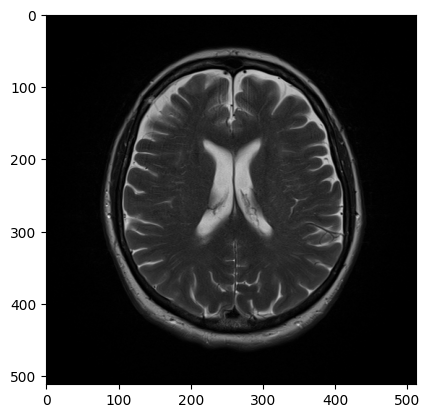

In [ ]:
plt.imshow(img_array, cmap='grey')

In [ ]:
# Scaling
# Min Max Scaling
# X - Xmin / Xmax - Xmin

img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array))

In [ ]:
h, w = img_array.shape # channels, c = 1 because black and white
pixels = img_array.reshape(h*w, 1)

In [ ]:
# Elbow Method

In [ ]:
sum_of_distances = []

In [ ]:
for i in range(2,11):
    model = KMeans(n_clusters=i)
    model.fit(pixels)
    sum_of_distances.append(model.inertia_)

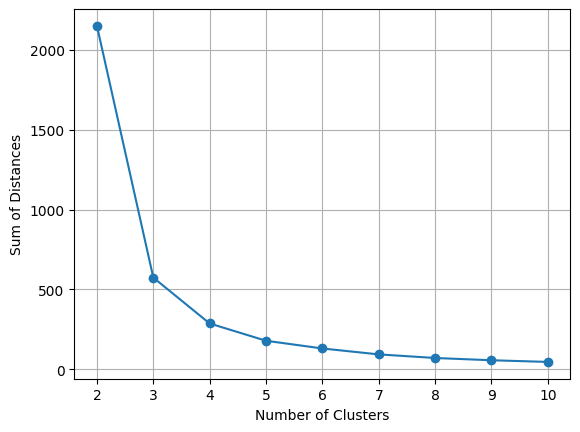

In [ ]:
plt.plot(range(2,11), sum_of_distances, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Distances')
plt.grid(True)

In [ ]:
model = KMeans(n_clusters=4)
group_number = model.fit_predict(pixels)


In [ ]:
segmented_image = model.cluster_centers_[group_number].reshape(h,w)

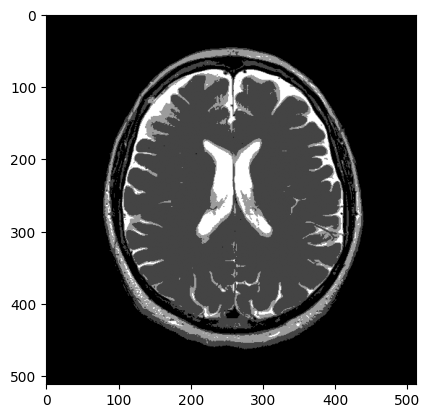

In [ ]:
plt.imshow(segmented_image, cmap='grey')

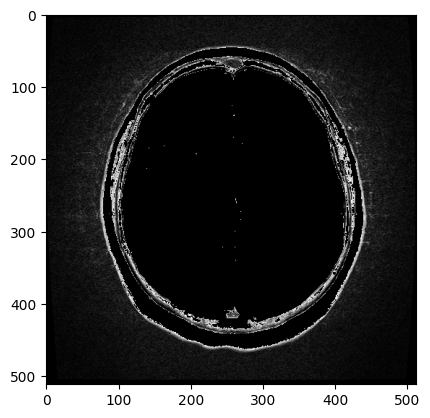

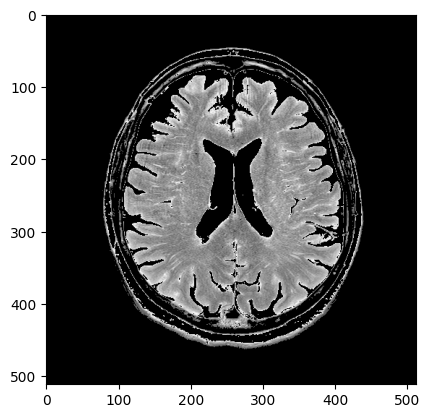

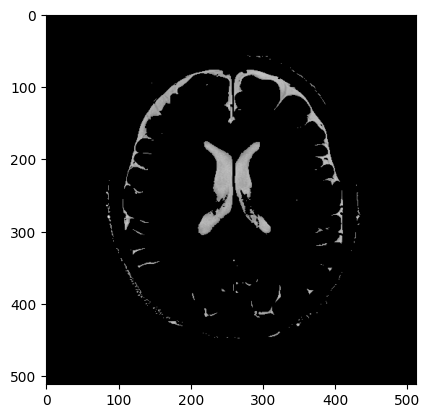

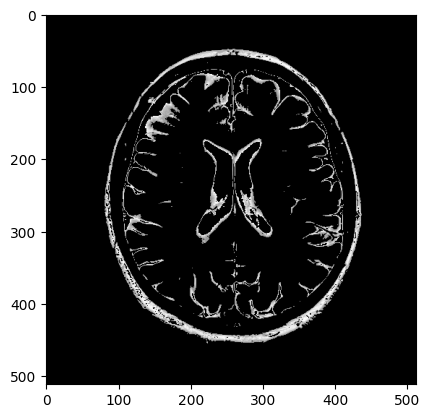

In [ ]:
for i in range(4):
    cluster_mask = group_number.reshape(h,w)==i
    segment = img_array * cluster_mask

    plt.figure()
    plt.imshow(segment, cmap='grey')